# Kelman Filtering

In [12]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt

# Add the libs directory to Python path
current_dir = os.path.dirname(os.path.abspath('KelmanFiltering.ipynb'))
libs_dir = os.path.join(current_dir, '..', 'libs')
libs_dir = os.path.abspath(libs_dir)
print("Libs directory:", libs_dir)
sys.path.insert(0, libs_dir)

from websocketclient import WebSocketCollector
from kelmanfilter import KalmanFilter


Libs directory: /Users/kolithawarnakulasooriya/Projects/AI-driven-cyber-physical-system/libs


In [34]:
ws_url = "ws://localhost:8000/ws"
message_queue = WebSocketCollector(ws_url, max_messages=1000).collect()
print("Collected messages:", message_queue.qsize())

WebSocket opened
WebSocket closed
Collected messages: 1000


In [35]:
print("Sample message:", message_queue.get())

raw_values = [message_queue.get() for _ in range(message_queue.qsize())]
values = [json.loads(value).get("data").get("value") for value in raw_values]
values = [float(value) for value in values if value is not None]
print("Extracted values:", values)

Sample message: {"type": "initial_state", "data": {"sensors": [{"id": "b83199f3-8f96-489c-9966-be2888d6c8fa", "name": "See", "type": "gaussian", "interval": 0.01, "min_value": 0, "max_value": 100, "is_running": true, "current_value": 35.745127347332456, "recording": false, "parameters": {}}], "mqtt_connected": false, "recordings": {}}}
Extracted values: [52.04838308229253, 33.52267717805781, 58.07264400919527, 50.60973048826539, 79.57275527897112, 64.90528786279488, 35.819616701790146, 48.25156232515986, 20.630903881313994, 39.39787364178084, 46.22489932467746, 50.56029951764775, 49.1522499114223, 50.06555249908114, 43.45455928938821, 52.80522150535148, 59.69596242972806, 35.170552781848, 32.84125621184806, 38.67477220267998, 40.018677451129996, 45.6335062227657, 46.959599768139086, 36.750753295121605, 38.3159502282756, 7.142080567810447, 34.84332214861882, 71.22415969431208, 62.688051387989454, 36.9863843978888, 35.999047347584515, 25.611029603488333, 42.17905104639107, 26.70479415694

In [36]:
# Enhanced Kalman filter using class
if 'values' in locals() and values:
    # Use advanced Kalman filter with velocity estimation
    kf = KalmanFilter(dt=1.0, 
                       process_variance=1e-5, 
                       measurement_variance=1e-2,
                       initial_position=values[0],
                       initial_velocity=0.0)
    
    filtered_values, velocities = kf.filter(values)
    
    print("=== Kalman Filter Results ===")
    print(f"Raw values (first 10): {values[:10]}")
    print(f"Filtered values (first 10): {[f'{v:.4f}' for v in filtered_values[:10]]}")
    print(f"Estimated velocities (first 10): {[f'{v:.4f}' for v in velocities[:10]]}")
    print(f"Mean squared error (Filter vs Raw): {np.mean([(f - r)**2 for f, r in zip(filtered_values, values)]):.6f}")


=== Kalman Filter Results ===
Raw values (first 10): [52.04838308229253, 33.52267717805781, 58.07264400919527, 50.60973048826539, 79.57275527897112, 64.90528786279488, 35.819616701790146, 48.25156232515986, 20.630903881313994, 39.39787364178084]
Filtered values (first 10): ['52.0484', '33.8706', '50.8163', '51.5519', '69.1199', '70.3265', '57.2329', '54.1705', '41.5809', '39.5111']
Estimated velocities (first 10): ['0.0000', '-17.6581', '2.9020', '1.9780', '7.1658', '5.5372', '1.2049', '0.3377', '-2.0085', '-2.0186']
Mean squared error (Filter vs Raw): 187.406424


(array([ 1.,  3.,  1.,  4., 12., 20., 21., 26., 30., 47., 56., 66., 67.,
        87., 85., 80., 67., 69., 61., 50., 39., 31., 27., 23., 12.,  4.,
         2.,  2.,  3.,  3.]),
 array([  1.71852101,   4.99457031,   8.27061961,  11.54666891,
         14.82271821,  18.09876751,  21.37481681,  24.65086611,
         27.92691541,  31.20296471,  34.47901401,  37.75506331,
         41.0311126 ,  44.3071619 ,  47.5832112 ,  50.8592605 ,
         54.1353098 ,  57.4113591 ,  60.6874084 ,  63.9634577 ,
         67.239507  ,  70.5155563 ,  73.7916056 ,  77.0676549 ,
         80.3437042 ,  83.6197535 ,  86.8958028 ,  90.1718521 ,
         93.4479014 ,  96.7239507 , 100.        ]),
 <BarContainer object of 30 artists>)

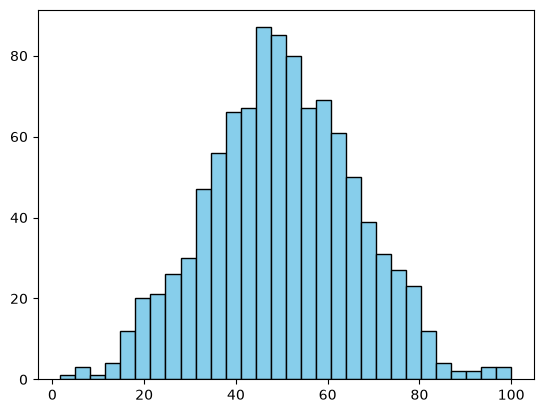

In [37]:
plt.hist(values, bins=30, color='skyblue', edgecolor='black')